In [5]:
import torch

In [6]:
import torchvision

In [7]:
from torchvision import transforms, datasets

In [8]:
from torch.utils.data import DataLoader

In [9]:
from torch import nn

In [10]:
from torch import optim

In [11]:
from torchvision.datasets import ImageFolder

In [12]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [13]:
train_dataset=ImageFolder(root='D:\\dataset\\train', transform=transform)
test_dataset=ImageFolder(root='D:\\dataset\\test', transform=transform)

In [14]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)

In [15]:
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [16]:
print(train_dataset.classes)
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

['normal', 'pneumonia']
Train size: 640, Test size: 160


In [17]:
import torch.nn as nn
model = nn.Sequential(

    # First Conv Block
    nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1), nn.ReLU(),

    nn.MaxPool2d(kernel_size=2,stride=2),

    # Second Conv Block
    nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1),nn.ReLU(),

    nn.MaxPool2d(kernel_size=2,stride=2),

    # Third Conv Block
    nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1),nn.ReLU(),

    nn.MaxPool2d(kernel_size=2,stride=2),

    # Flatten Layer
    nn.Flatten(),

    # Fully Connected Layer
    nn.Linear(128 * 16 * 16,128),

    nn.ReLU(),

    # Output Layer
    nn.Linear(128,2)

)

print(model)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=32768, out_features=128, bias=True)
  (11): ReLU()
  (12): Linear(in_features=128, out_features=2, bias=True)
)


In [18]:
criterion = nn.CrossEntropyLoss()

In [19]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001 ## learning rate
)

In [39]:
num_epochs = 10

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()
        
    #epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 14.9165
Epoch [2/10], Loss: 11.4992
Epoch [3/10], Loss: 8.4428
Epoch [4/10], Loss: 6.6847
Epoch [5/10], Loss: 5.8350
Epoch [6/10], Loss: 5.4256
Epoch [7/10], Loss: 5.1798
Epoch [8/10], Loss: 5.3143
Epoch [9/10], Loss: 5.1237
Epoch [10/10], Loss: 4.4494


In [25]:
import pickle

with open("chest_xray_model(CNN).pkl", "wb") as f:
    pickle.dump(model, f)

In [40]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 96.88%


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os                                            ### TESTING on a single image 
import pickle                                                     ### Using GRAD CAM which part is affected

from PIL import Image

from pytorch_grad_cam import GradCAM   ## pip install Grad-cam
from pytorch_grad_cam.utils.image import show_cam_on_image

Prediction: pneumonia


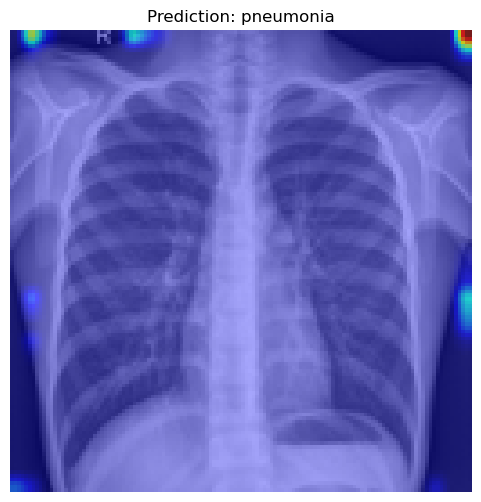

In [28]:

image_path = "C:\\Users\\senku\\OneDrive\\Desktop\\New folder\\wrong prediction\\normal chest_non_dataset.jpeg"

image_name = os.path.basename(image_path)

# Load original image
original_image = Image.open(image_path).convert("L")

# Transform for model
input_tensor = transform(original_image).unsqueeze(0)

# Prediction
with open("chest_xray_model(CNN).pkl", "rb") as f:   ## load the models PKL
    model = pickle.load(f)


model.eval()

#Classes
classes = ['normal', 'pneumonia']


with torch.no_grad():

    output = model(input_tensor)
    _, predicted = torch.max(output, 1)

predicted_class = classes[predicted.item()]

print("Prediction:", predicted_class)


# Grad-CAM

target_layer = model[6]

cam = GradCAM(model=model,target_layers=[target_layer])

# Generate CAM
grayscale_cam = cam(input_tensor=input_tensor)

grayscale_cam = grayscale_cam[0]

# Prepare image for overlay
rgb_image = np.array(original_image.resize((128,128))) / 255.0

# Convert grayscale to RGB
rgb_image = np.stack([rgb_image]*3, axis=-1)

# Overlay heatmap
visualization = show_cam_on_image(rgb_image,grayscale_cam,use_rgb=True)


# Display
plt.figure(figsize=(6,6))

plt.imshow(visualization)

plt.title(f"Prediction: {predicted_class}")


plt.axis("off")

save_name = f"sample_output_{image_name}"
plt.savefig(
    save_name,
    bbox_inches='tight'
)

plt.show()

In [58]:
import pandas as pd
predictions = []

with torch.no_grad():

    for image_path, label in test_dataset.samples:

        # Load image
        image = Image.open(image_path).convert("L")

        # Transform
        input_tensor = transform(image).unsqueeze(0)

        # Prediction
        output = model(input_tensor)

        _, predicted = torch.max(output, 1)

        predicted_label = classes[predicted.item()]

        # Extract filename
        image_name = image_path.split("\\")[-1]

        # Save result
        predictions.append([image_name, predicted_label])

In [59]:
df = pd.DataFrame(
    predictions,
    columns=["image_name", "label"]
)

In [60]:
df.to_csv(
    "predictions.csv",
    index=False
)

In [61]:
df.head()

,image_name,label
0,IM-0115-0001.jpeg,normal
1,IM-0177-0001.jpeg,normal
2,IM-0182-0001.jpeg,normal
3,IM-0187-0001.jpeg,normal
4,IM-0193-0001.jpeg,normal


In [62]:
print(len(test_dataset.samples))


160


In [41]:
os.makedirs("outputs", exist_ok=True)

with open("outputs/metrics.txt", "w") as f:

    f.write("Chest X-ray Classification Metrics\n")
    f.write("--------------------------------\n")

    f.write(f"Test Accuracy: {accuracy:.2f}%\n")

    f.write("Model: Simple CNN\n")

    f.write("Input Size: 128x128\n")

    f.write("Batch Size: 32\n")

    f.write("Optimizer: Adam\n")

    f.write("Loss Function: CrossEntropyLoss\n")